# Test augmented data on different models

In [26]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mping
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Define functions

In [51]:
def load_data(dir_path):
    x = []
    y = []
    for class_dir in dir_path.iterdir():
        print(f"Loading dataset {class_dir}")
        if class_dir.is_dir():
    
            for img_file in class_dir.iterdir():
                if img_file.is_file():
                    img = cv2.imread(img_file)
                    img = cv2.resize(img, (32, 32))
                    img = np.array(img)
                    img = img / 255.0
                    x.append(img)
                    y.append(class_dir.name)
    return x, y

def vorhersage_aus_generatorbild(model, bild_array, true_label, class_names=None, threshold=0.5):
    try:
        if len(bild_array.shape) == 3:
            bild_vor_model = np.expand_dims(bild_array, axis=0)
        elif len(bild_array.shape) == 4 and bild_array.shape[0] == 1:
            bild_vor_model = bild_array
        else:
            raise ValueError(f"Unerwartete Eingabeform: {bild_array.shape}")

        vorhersage = model.predict(bild_vor_model, verbose=0)
        wahrscheinlichkeit_waldbrand = vorhersage[0][0]  # sigmoid-Ausgabe

        klasse_name = 'Waldbrand' if wahrscheinlichkeit_waldbrand > threshold else 'Kein Waldbrand'

        # → Wahre Klasse bestimmen
        if class_names:
            true_klasse_name = class_names[np.argmax(true_label)]
        else:
            true_klasse_name = 'Waldbrand' if np.argmax(true_label) == 1 else 'Kein Waldbrand'

        # Anzeige vorbereiten
        bild_anzeige = (bild_array * 255).astype(np.uint8)
        if bild_anzeige.shape[-1] == 3:
            bild_anzeige = cv2.cvtColor(bild_anzeige, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(bild_anzeige)
        plt.title(f'Vorhersage: {klasse_name}\nTatsächlich: {true_klasse_name}', fontsize=12, fontweight='bold')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        waldbrand_conf = wahrscheinlichkeit_waldbrand * 100
        kein_waldbrand_conf = (1 - wahrscheinlichkeit_waldbrand) * 100

        bars = plt.barh(['Waldbrand', 'Kein Waldbrand'],
                        [waldbrand_conf, kein_waldbrand_conf],
                        color=['crimson', 'forestgreen'])

        for bar in bars:
            width = bar.get_width()
            plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                     f'{width:.1f}%', ha='left', va='center', fontweight='bold')

        plt.xlim([0, 105])
        plt.title('Konfidenz (%)', fontsize=12, fontweight='bold')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.gca().set_facecolor('#ffeeee' if klasse_name == 'Waldbrand' else '#eeffee')

        plt.axvline(x=threshold*100, color='blue', linestyle='--', linewidth=2)
        plt.text(threshold*100 + 1, 0.5, f'Schwellenwert ({threshold*100:.0f}%)',
                 ha='left', va='center', color='blue', fontweight='bold')

        plt.tight_layout()
        plt.show()

        return klasse_name, true_klasse_name, wahrscheinlichkeit_waldbrand

    except Exception as e:
        print(f"Fehler bei der Bildvorhersage: {e}")
        return None, None, None


#### Load data

In [8]:
x_test, y_test = load_data(Path("dataset/test"))

Loading dataset dataset\test\nowildfire
Loading dataset dataset\test\wildfire


In [9]:
print("Number of images in test:", len(x_test))
print("Shape of first image in train:", x_test[0].shape)
print("First label in train:", y_test[0])

Number of images in test: 6300
Shape of first image in train: (32, 32, 3)
First label in train: nowildfire


i = 5333


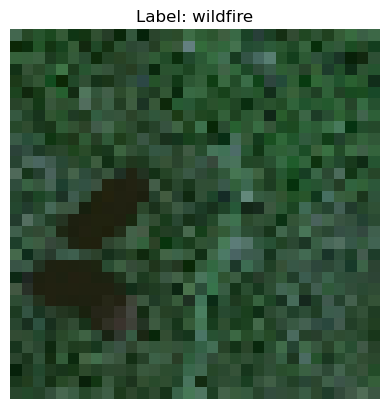

i = 3432


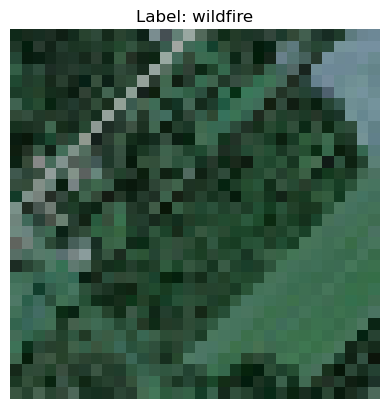

i = 862


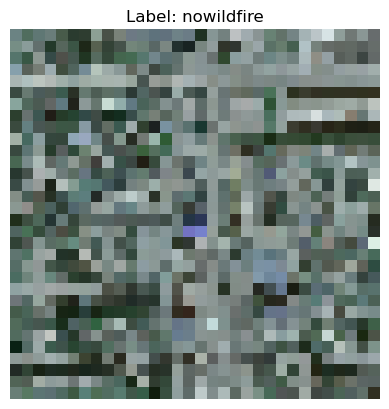

i = 1378


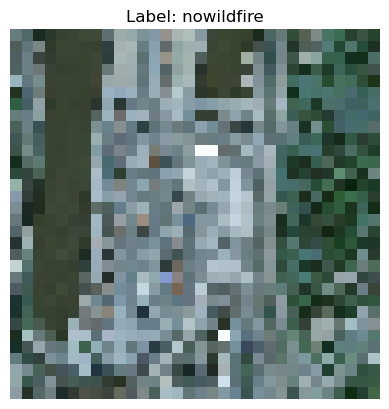

i = 1749


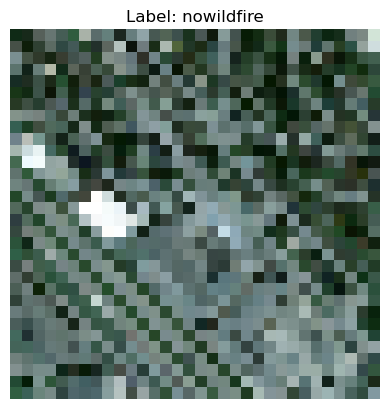

In [10]:
for i in random.sample(range(len(x_test)),5):
    print(f"i = {i}")
    plt.imshow(x_test[i])
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
    plt.show()

#### Encode labels

Machine learning models can't understand "wildfire" or "nowildfire" directly — they need numerical representations. We use the label_map here to turn strings into class indices (e.g., ["wildfire", "nowildfire"] → [0, 1])

In [16]:
label_map = {'nowildfire':0, 'wildfire':1}
y_test_encoded = [label_map[label] for label in y_test]
# print(y_train_encoded)
# print(y_valid_encoded)

#### Convert lists to numpy arrays

In [19]:
x_test = np.array(x_test)
y_test_encoded = np.array(y_test_encoded)

#### Load neural network

In [39]:
baseline = keras.models.load_model("models/baseline.keras")

#### Data Augmentation

In [32]:
test_datagen = ImageDataGenerator(
    rotation_range=0,
    width_shift_range=0,
    height_shift_range=0,
    shear_range=0,
    zoom_range=0,
    horizontal_flip=False,
    vertical_flip=False
)

batch_size = 1

test_generator = test_datagen.flow(
    x_test, y_test_encoded,
    batch_size=batch_size,
    shuffle=True
)

#### Plot results

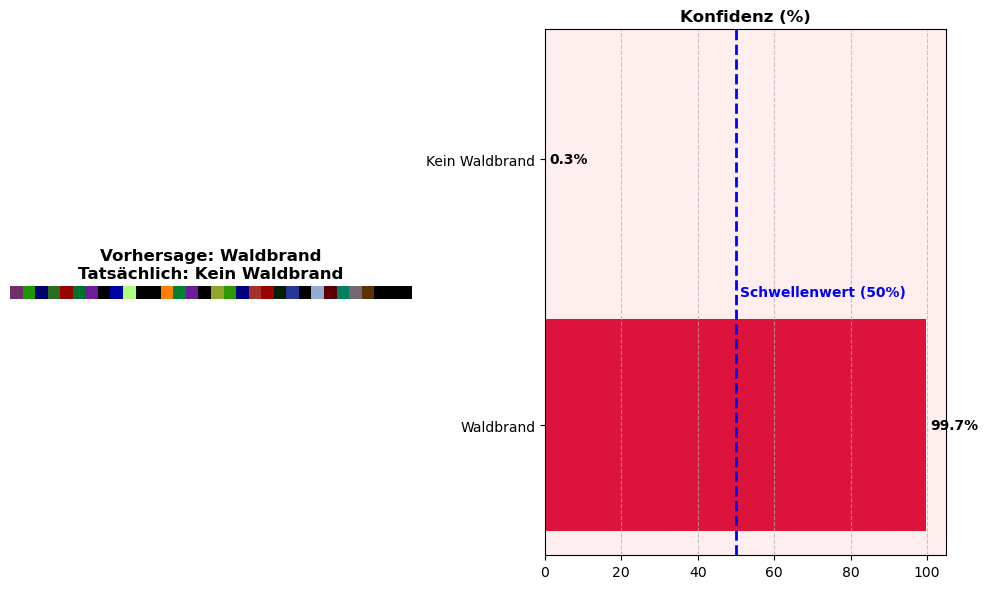

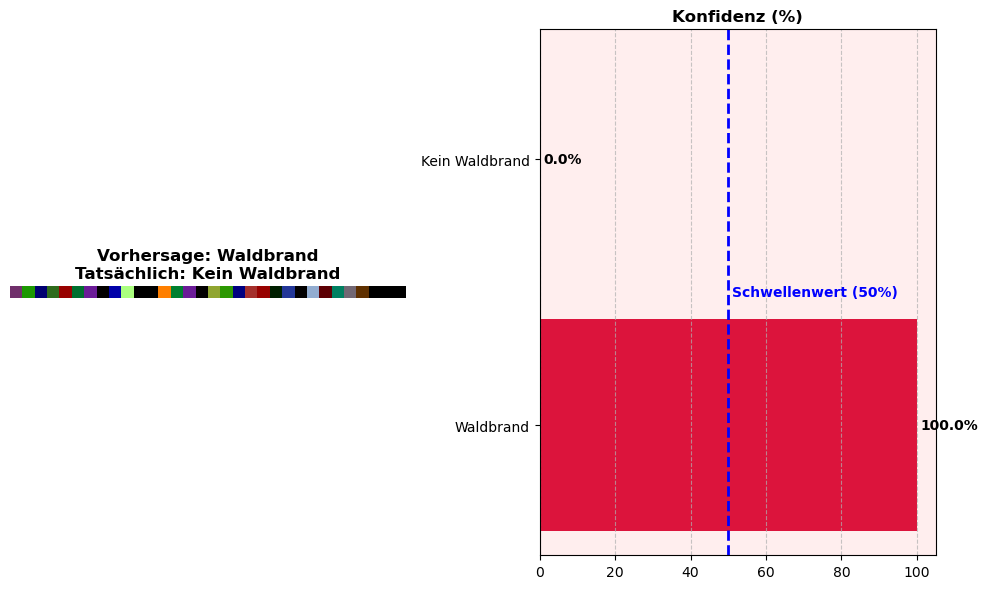

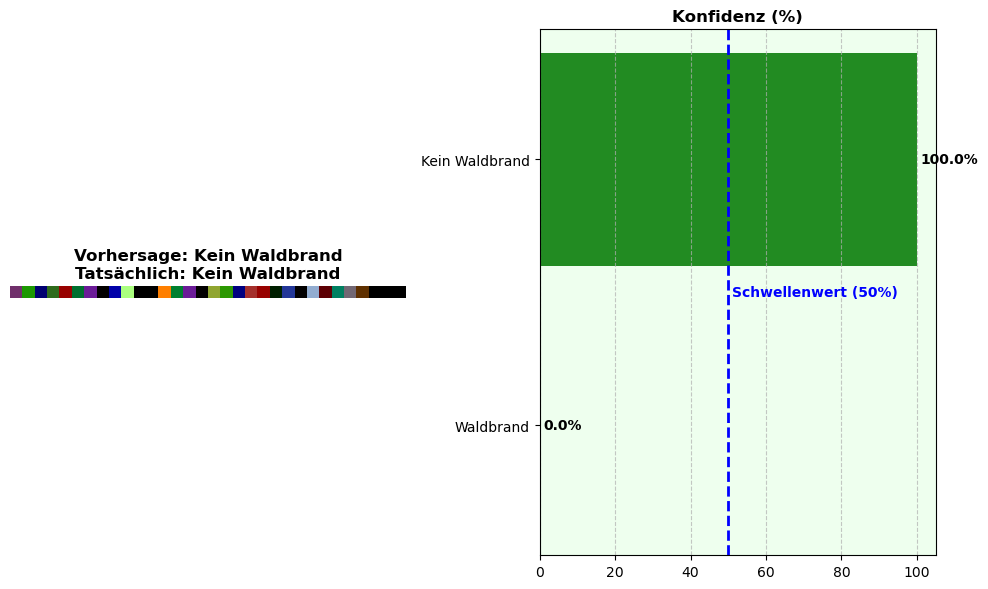

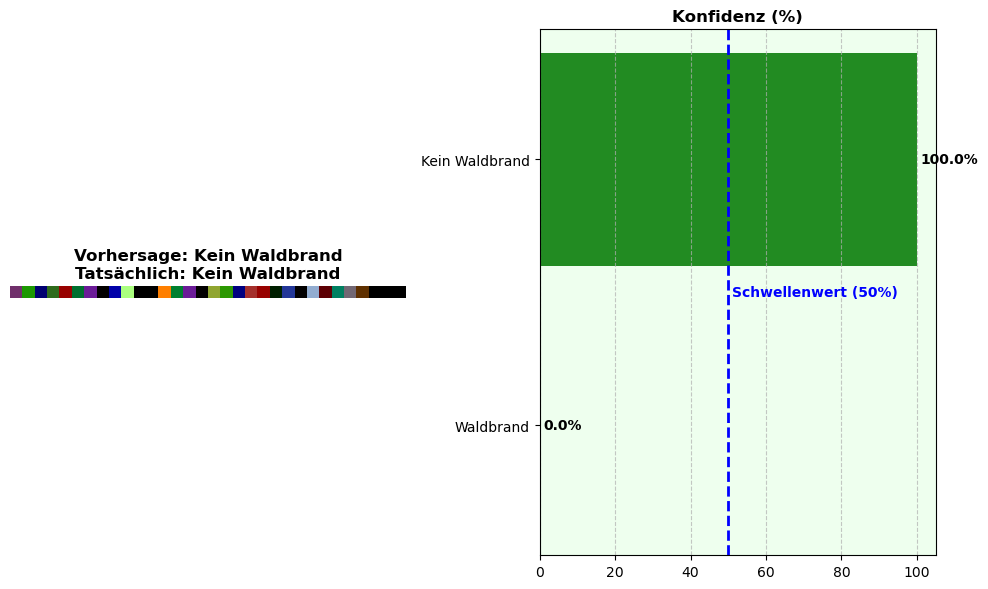

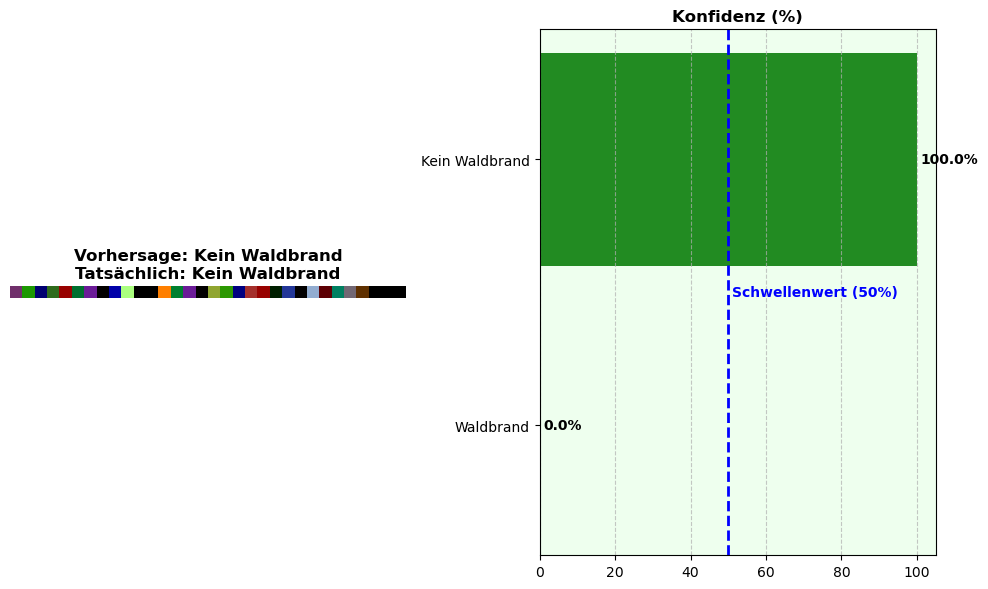

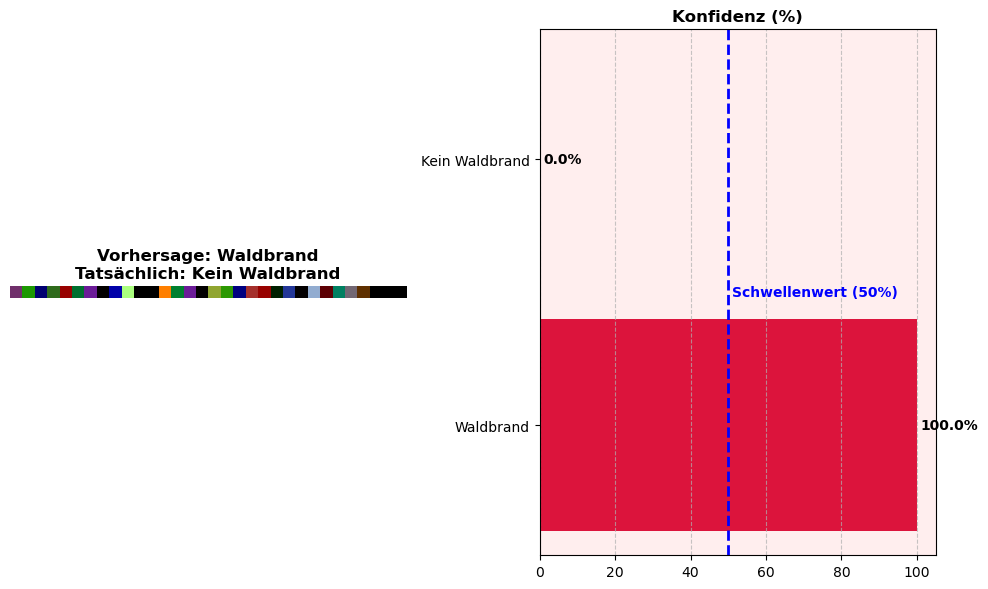

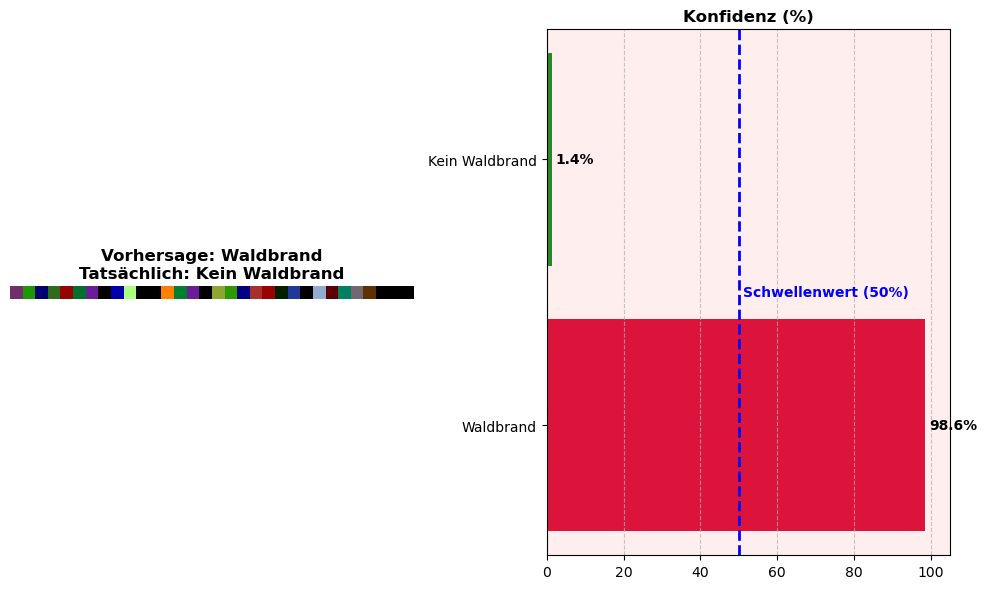

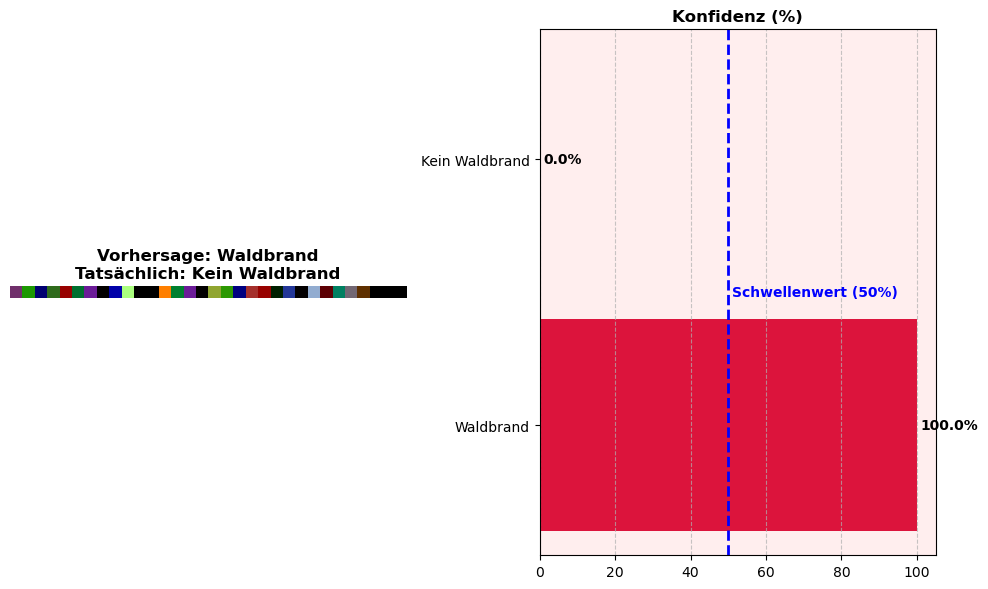

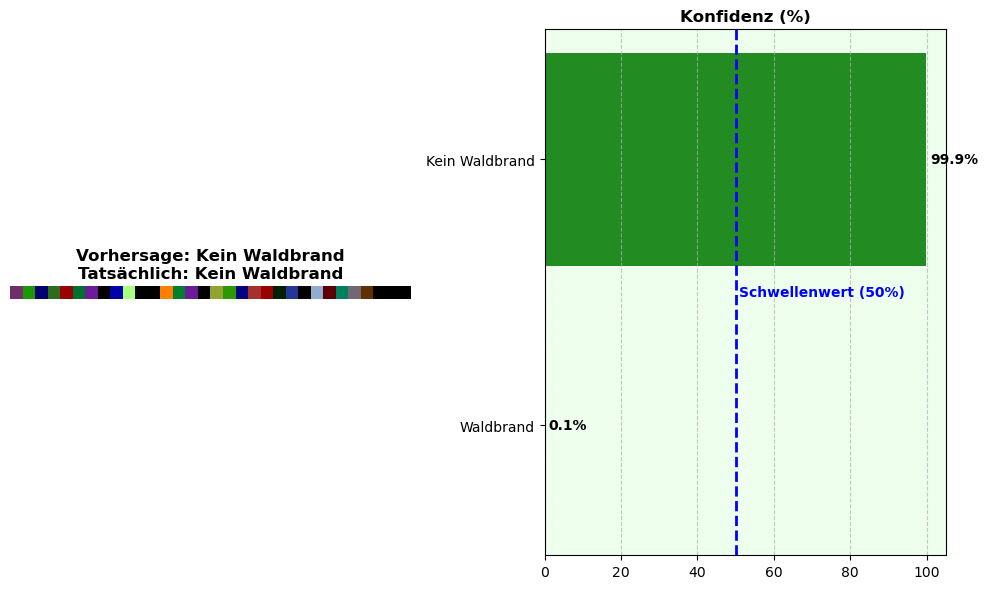

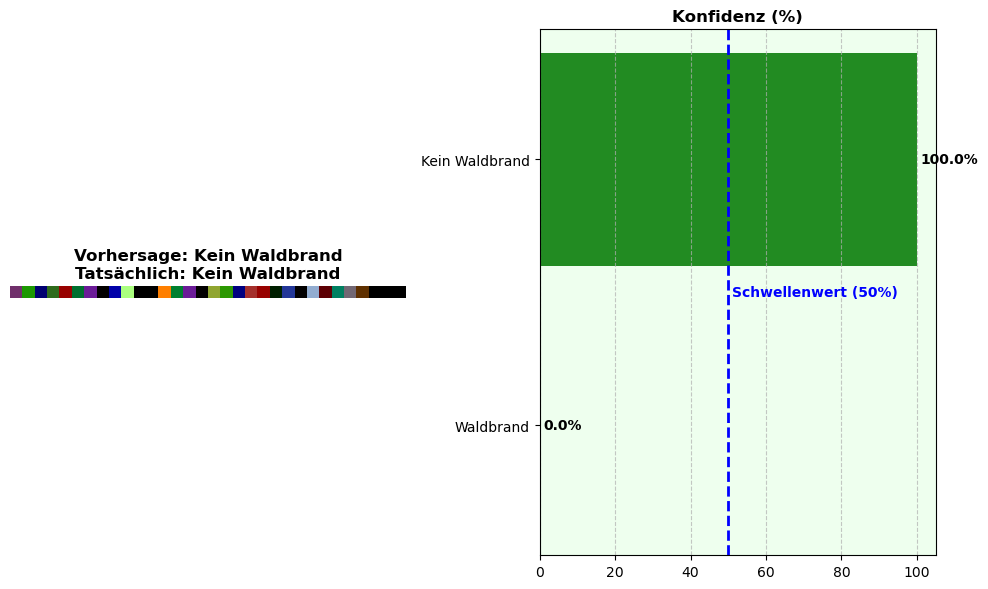

In [53]:
for i in range(10):
    bild, label = next(test_generator)
    vorhersage_aus_generatorbild(baseline, bild, label)

___